### State Schema with Data Classes

When we define a LangGraph StateGraph, we use state Schema

The State Schema represents the structure and types of data that our graph will use.

All nodes are expected to communicate with that schema

LangGraph offers Flexibility in how you define your state schema, accommodating various Python types and validation approaches!

In [2]:
from typing_extensions import TypedDict
from typing import Literal
import random

class TypedDictState(TypedDict): # they are not enforced at run-time
    name: str
    game: Literal["cricket","tennis"]

In [3]:
def play_game(state: TypedDictState):
    print("play game node has been called")
    return {"name": state["name"]}

def cricket(state: TypedDictState):
    print("cricket node has been called")
    return { "name":state["name"] + "cricket","game": "cricket"}

def tennis(state: TypedDictState):
    print("tennis node has been called")
    return {"name":state["name"] + "cricket","game": "tennis"}

In [4]:
def decide_play(state: TypedDictState) -> Literal["cricket", "tennis"]:
    if random.random() < 0.5:
        return "cricket"
    else:
        return "tennis"

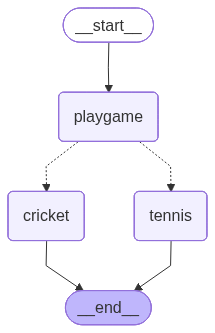

In [5]:
import random
from IPython.display import Image,display
from langgraph.graph import StateGraph,START,END

builder=StateGraph(TypedDictState)

builder.add_node("playgame",play_game)
builder.add_node("cricket",cricket)
builder.add_node("tennis",tennis)

builder.add_edge(START,"playgame")
builder.add_conditional_edges("playgame",decide_play)
builder.add_edge("cricket",END)
builder.add_edge("tennis",END)

graph_builder=builder.compile()

display(Image(graph_builder.get_graph().draw_mermaid_png()))


In [6]:
graph_builder.invoke({"name":"divyansh"})

play game node has been called
tennis node has been called


{'name': 'divyanshcricket', 'game': 'tennis'}

In [8]:
graph_builder.invoke({"name":"123"})

play game node has been called
tennis node has been called


{'name': '123cricket', 'game': 'tennis'}

### Pydantic - data validationsm

## Data Classes
* Python dataclasses provides another way to define structured data.
* DataClasses offer a concise syntax for creating classes that are primarily used to store data.

In [9]:
from dataclasses import dataclass

@dataclass
class DataClassState:
    name: str
    game: Literal["cricket","tennis"]

In [11]:
def play_game(state: DataClassState):
    print("play game node has been called")
    return {"name": state.name}

def cricket(state: DataClassState):
    print("cricket node has been called")
    return { "name":state.name + "cricket","game": "cricket"}

def tennis(state: DataClassState):
    print("tennis node has been called")
    return {"name":state.name + "cricket","game": "tennis"}

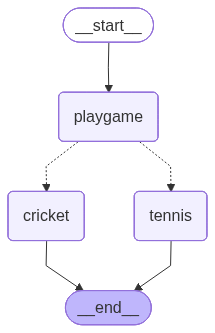

In [13]:
builder=StateGraph(DataClassState)

builder.add_node("playgame",play_game)
builder.add_node("cricket",cricket)
builder.add_node("tennis",tennis)

builder.add_edge(START,"playgame")
builder.add_conditional_edges("playgame",decide_play)
builder.add_edge("cricket",END)
builder.add_edge("tennis",END)

graph_builder=builder.compile()

display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [22]:
graph_builder.invoke(DataClassState(name="divyansh ", game="cricket"))

play game node has been called
cricket node has been called


{'name': 'divyansh cricket', 'game': 'cricket'}